In [32]:
import gdsfactory as gf
from gsim.palace import DrivenSim

gf.gpdk.PDK.activate()

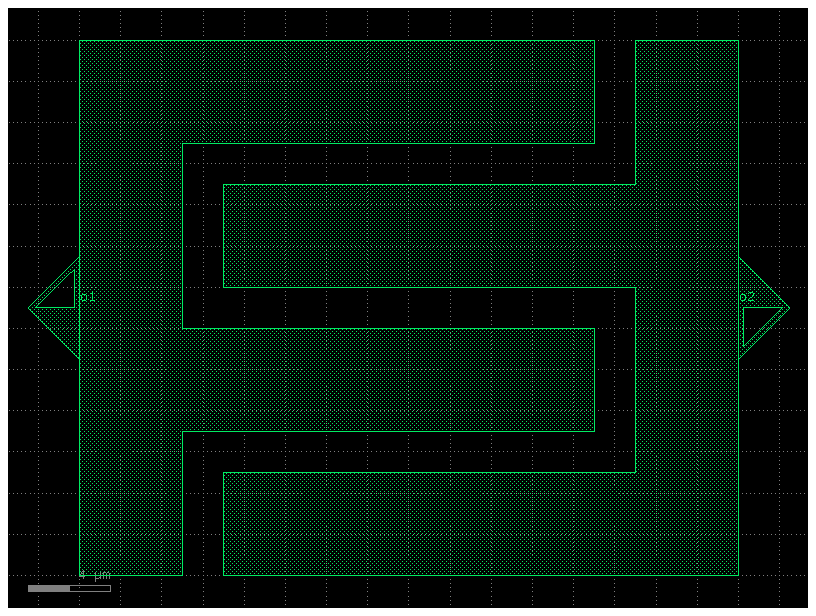

In [33]:
c=gf.components.interdigital_capacitor(
    fingers=4,
    finger_length=20,
    finger_gap=2,
    thickness=5,
    layer='M1'
    )

cc = gf.boolean(
    A=c,
    B=c,
    operation="or",
    layer="M1"
)

cc.add_ports(c.ports)
cc.draw_ports()

cc.plot()

In [37]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-idc")
sim.set_geometry(cc)

sim.set_stack(
    substrate_thickness=2.0,
    air_above=200.0,
)

sim.add_port("o1",layer="M1",length=5.0)
sim.add_port("o2",layer="M1",length=5.0)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [38]:
sim.mesh(preset="fine")

Mesh Summary
Dimensions: 237.0 x 226.0 x 307.6 µm
Nodes:      1,109
Elements:   8,636
Tetrahedra: 5,970
Edge length: 0.32 - 126.00 µm
Quality:    0.516 (min: 0.001)
SICN:       0.552 (all valid)
----------------------------------------
Volumes (4):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - airbox [4]
Surfaces (3):
  - metal1_xy [5]
  - metal1_z [6]
  - Absorbing_boundary [7]
----------------------------------------
Mesh:   ../palace-sim-idc/palace.msh

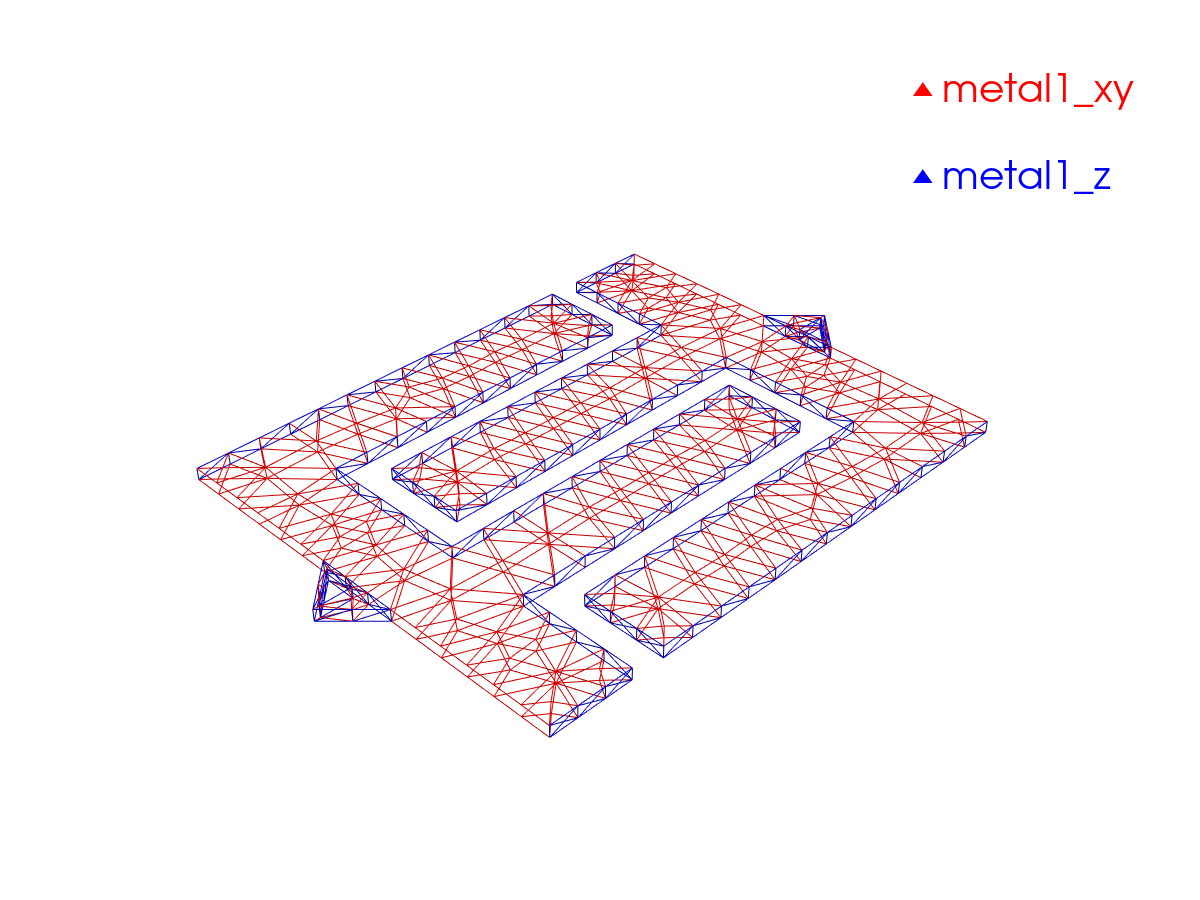

In [39]:
sim.plot_mesh(show_groups=["metal", "P"], interactive=False)